In [303]:
import numpy as np
import pandas as pd
import yfinance as yf
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [305]:
end_date = datetime.strptime('2020-01-01', '%Y-%m-%d')
start_date = end_date - timedelta(days=365*5)

portfolio = ['GOOGL', 'TSLA', 'AMZN', 'JPM', 'XOM', 'ASML', 'RACE', 'SIE.DE', 'GLD', 'BTC-USD']

returns_df = pd.DataFrame()

for ticker in portfolio:
    data = yf.download(ticker, start=start_date, end=end_date, interval='1mo')
    returns_df[ticker] = data['Close'].pct_change()

returns_df = returns_df.dropna()
print(returns_df.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2019-08-01 -0.022714 -0.066222 -0.048474 -0.046226 -0.079075 -0.000898   
2019-09-01  0.025711  0.067639 -0.022733  0.071272  0.043925  0.115943   
2019-10-01  0.030840  0.307427  0.023475  0.061433 -0.043054  0.054545   
2019-11-01  0.035979  0.047695  0.013587  0.063204  0.008288  0.033019   
2019-12-01  0.027069  0.267897  0.026122  0.057984  0.036570  0.098312   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2019-08-01 -0.020673 -0.081220  0.079123 -0.045110  
2019-09-01 -0.023201  0.080264 -0.033948 -0.138806  
2019-10-01  0.039133  0.052214  0.025635  0.109203  
2019-11-01  0.050899  0.132908 -0.032086 -0.177177  
2019-12-01 -0.016224 -0.004952  0.036559 -0.049676  


In [330]:
mean_returns = returns_df.mean() 
cov_matrix = returns_df.cov()
num_assets = len(portfolio)
risk_free_rate = 0.00017

# Frontiera Efficiente Long-only
target_returns = np.linspace(mean_returns.min(), mean_returns.max(), 50)

frontier_returns = []
frontier_risks = []
weights_list = []

for target_return in target_returns:
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w: w @ mean_returns - target_return}
    ]
    bounds = tuple((0, 1) for _ in range(num_assets))
    init_weights = np.ones(num_assets) / num_assets

    result = minimize(
        lambda w: np.sqrt(w.T @ cov_matrix @ w),
        init_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    if result.success:
        weights = result.x
        port_return = weights @ mean_returns
        port_risk = np.sqrt(weights.T @ cov_matrix @ weights)

        frontier_returns.append(port_return)
        frontier_risks.append(port_risk)
        weights_list.append(weights)

In [331]:
# 4. Portafoglio a rischio minimo
constraints_min_var = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = tuple((0, 1) for _ in range(num_assets))
init_weights = np.ones(num_assets) / num_assets

min_var_result = minimize(
    lambda w: np.sqrt(w.T @ cov_matrix @ w),
    init_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints_min_var
)

min_var_weights = min_var_result.x
min_var_return = min_var_weights @ mean_returns
min_var_risk = np.sqrt(min_var_weights.T @ cov_matrix @ min_var_weights)

In [332]:
# 5. Portafoglio a massimo Sharpe Ratio
def negative_sharpe(w):
    port_return = w @ mean_returns
    port_risk = np.sqrt(w.T @ cov_matrix @ w)
    return - (port_return - risk_free_rate) / port_risk

sharpe_result = minimize(
    negative_sharpe,
    init_weights,
    method='SLSQP',
    bounds=bounds,
    constraints=constraints_min_var
)

In [333]:
sharpe_weights = sharpe_result.x
sharpe_return = sharpe_weights @ mean_returns
sharpe_risk = np.sqrt(sharpe_weights.T @ cov_matrix @ sharpe_weights)
sharpe_ratio = (sharpe_return - risk_free_rate) / sharpe_risk

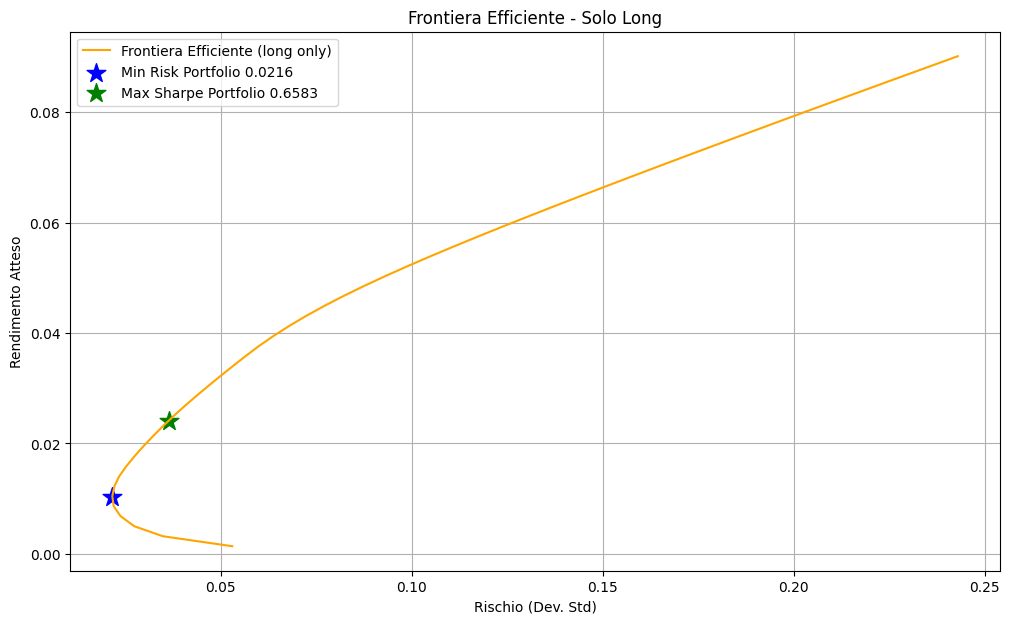

In [334]:
plt.figure(figsize=(12, 7))

plt.plot(frontier_risks, 
         frontier_returns, 
         color='orange', 
         label='Frontiera Efficiente (long only)')

plt.scatter(min_var_risk, 
            min_var_return, 
            color='blue', 
            label=f'Min Risk Portfolio {min_var_risk:.4f}', 
            marker='*', s=200)

plt.scatter(sharpe_risk, 
            sharpe_return, 
            color='green', 
            label=f'Max Sharpe Portfolio {sharpe_ratio:.4f}', 
            marker='*', 
            s=200)

plt.xlabel('Rischio (Dev. Std)')
plt.ylabel('Rendimento Atteso')
plt.title('Frontiera Efficiente - Solo Long')
plt.legend()
plt.grid(True)
plt.show()

In [335]:
print("\n➡️  Pesi Portafoglio a Minimo Rischio:")
print(pd.Series(min_var_weights, index=portfolio).round(4))

print("\n🌟 Pesi Portafoglio a Massimo Sharpe Ratio:")
print(pd.Series(sharpe_weights, index=portfolio).round(4))


➡️  Pesi Portafoglio a Minimo Rischio:
GOOGL      0.1445
TSLA       0.0000
AMZN       0.0000
JPM        0.1783
XOM        0.0632
ASML       0.0000
RACE       0.0000
SIE.DE     0.0914
GLD        0.5154
BTC-USD    0.0072
dtype: float64

🌟 Pesi Portafoglio a Massimo Sharpe Ratio:
GOOGL      0.0000
TSLA       0.0253
AMZN       0.0591
JPM        0.2427
XOM        0.0000
ASML       0.2536
RACE       0.0238
SIE.DE     0.0000
GLD        0.3053
BTC-USD    0.0903
dtype: float64


In [336]:
# Creo un dataframe per registrare la performance dal 2020
performance_df = pd.DataFrame()

start_date2 = datetime.strptime('2020-01-01', '%Y-%m-%d')
end_date2 = datetime.strptime('2025-01-01', '%Y-%m-%d')

for ticker in portfolio:
    data2 = yf.download(ticker, start=start_date2, end=end_date2, interval='1mo')
    performance_df[ticker] = data2['Close'].pct_change()

performance_df = performance_df.dropna() 
print(performance_df.tail())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


               GOOGL      TSLA      AMZN       JPM       XOM      ASML  \
Date                                                                     
2024-08-01 -0.047569 -0.077390 -0.045352  0.062245 -0.005481 -0.033261   
2024-09-01  0.015118  0.221942  0.043866 -0.062011  0.001897 -0.078131   
2024-10-01  0.033084 -0.045025  0.000376  0.052452 -0.003754 -0.192859   
2024-11-01 -0.012624  0.381469  0.115290  0.132166  0.010104  0.020906   
2024-12-01  0.120450  0.170008  0.055318 -0.040085 -0.080587  0.009423   

                RACE    SIE.DE       GLD   BTC-USD  
Date                                                
2024-08-01  0.202852  0.002951  0.020922 -0.087425  
2024-09-01 -0.053705  0.067208  0.050889  0.073929  
2024-10-01  0.012274 -0.016213  0.042993  0.108728  
2024-11-01 -0.087669  0.026682 -0.031241  0.373621  
2024-12-01 -0.021467  0.035161 -0.014088 -0.031310  


In [337]:
weighted_returns = pd.DataFrame()

for date in performance_df.index:
    max_sr_return = sum(performance_df.loc[date] * sharpe_weights)
    weighted_returns.loc[date, 'Optimal'] = max_sr_return
    min_var_return = sum(performance_df.loc[date] * min_var_weights)
    weighted_returns.loc[date, 'Min Risk'] = min_var_return

cumulative_returns = weighted_returns.cumsum() * 100
print("-" * 50)
print(cumulative_returns.tail())

--------------------------------------------------
               Optimal   Min Risk
2024-08-01  115.278404  71.956394
2024-09-01  114.704828  74.371966
2024-10-01  113.298855  77.907576
2024-11-01  120.891145  79.047958
2024-12-01  120.149384  79.137389


In [338]:
sp500_data = yf.download('SPY', start=start_date2, end=end_date2, interval='1mo')
sp500_returns = sp500_data['Close'].pct_change()
sp500_cumulative_returns = sp500_returns.cumsum() * 100

variance = sp500_cumulative_returns.iloc[-1] - sp500_cumulative_returns.iloc[1]
print(variance)

print(sp500_cumulative_returns.tail())

[*********************100%***********************]  1 of 1 completed

Ticker
SPY    83.95467
dtype: float64
Ticker            SPY
Date                 
2024-08-01  71.608275
2024-09-01  73.396523
2024-10-01  72.808166
2024-11-01  78.771507
2024-12-01  76.038118


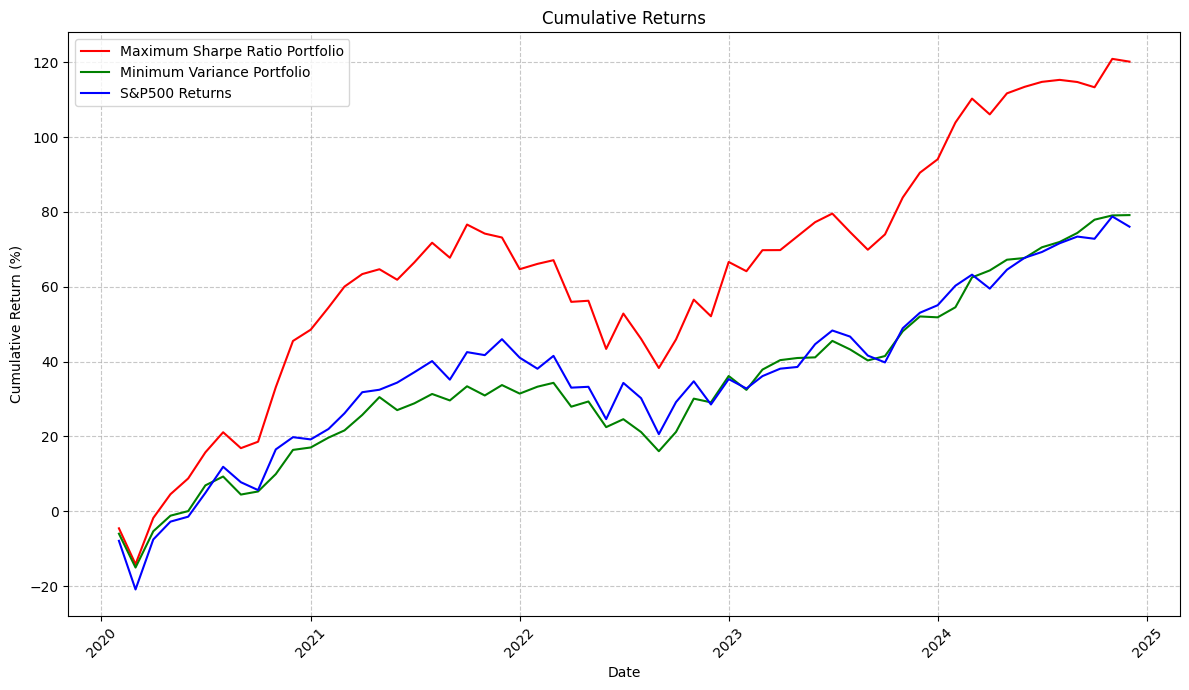

In [339]:
plt.figure(figsize=(12, 7))

plt.plot(cumulative_returns['Optimal'], 
         label='Maximum Sharpe Ratio Portfolio', 
         color='red')

plt.plot(cumulative_returns['Min Risk'], 
         label='Minimum Variance Portfolio', 
         color='green')

plt.plot(sp500_cumulative_returns,
         label='S&P500 Returns',
         color='blue')

plt.title('Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()